In [1]:
from IPython.core.display import HTML
import urllib.request
def css_styling():
    with urllib.request.urlopen("https://raw.githubusercontent.com/uolphysicsteaching/resources/main/notebook.css") as response:
        return HTML(response.read().decode("utf-8"))
css_styling()

In [2]:
import numpy as np
from matplotlib import pyplot as plt

from modules.MDLJMeasurement import MDLJMeasurement
from modules.MDLJTrajectory import MDLJTrajectory

<hr class='double' />

# Assignment Sheet 1
*Everyone should try these tasks and raise questions for the workshop if you don't understand something here.*

The tasks you will need to perform in order to proceed through the assessment are denoted **Task 1**, **Task 2**, **Task 3** etc.

The assessed questions are denoted **Q1**,**Q2**,**Q3** etc, so answer these questions in the space provided. The combination of **Tasks** and **Qs** will guide you through the process :)

**DO NOT**, I repeat, **DO NOT** copy the entire simulation code into this assessment notebook. If you do it will crash the autograder. Instead, run all the required simulations in a separate notebook and then do your analysis here. Once the trajectory and measurement files have been created (using a separate notebook) you can open them in this notebook. It is best to have copies of the simulation notebook, the assignment notebook and the "modules" folder from the software all in the same directory. Then you can do everything together :) 

## Aims
- To demonstrate an understanding of simulation timescales
- To develop an understanding of ensemble averages in calculations
- To develop an understanding of diffusion

---

## Pre-Assignment Work

Before every assignment, I advise you do the following:

- Create a new folder on your computer called "Assignment 1", "Assignment 2" etc
- Into that folder, place a copy of the "MolecularDynamics-Simulator.ipynb"
- Into that folder, place a copy of the "modules/" folder
- Into that folder, place a copy of the assignment notebook you are working on ("Phys3190_MD_Assignment1.ipynb", "Phys3190_MD_Assignment2.ipynb" etc)

If you do this, you can perform simualtions using "MolecularDynamics-Simulator.ipynb" and complete the assignment without ever having to change directory! 

<hr class='double' />

## Assignment Begins
For this assignment we are going to set up, run, and analyse a single simulation.

<div class='task'>
    
**Task 1:** Have a read through the simulation code and try to conceptually understand what it does. Feel free to ask any questions in the workshops, there are no stupid questions!
</div>

The default values in the notebook are not very useful to us. We will need to change them.

For our simulation, the simulation parameters will be as follows:

- Simulation Type: "Brownian"
- Number of Particles: 400
- Volume fraction: 0.01
- Temperature: 298 K
- Solvent viscosity: 1 MPa.ns
- Particle radius: 2 nm
- Particle density: 1 kDa/nm$^3$
- Simulation box boundary conditions: pbc

<div class='task'>
    
**Task 2:** Assign the above parameters into the `params` object in your simulation. Set the `params.LJ` variables to anything you like that is greater than zero.
</div>

You'll note that there are a few parameters we haven't assigned yet. This is because we will need to calculate them! Let's start that process with our first question.

Recall that for a single, spherical particle diffusing through a background medium, in one-dimension:

$$
\langle (x- x_0)^2 \rangle = 2Dt,
$$
and therefore, in three-dimensions:
$$
\langle \left| \vec{r}- \vec{r}_0\right|^2 \rangle = \langle (x- x_0)^2 \rangle + \langle (y- y_0)^2 \rangle + \langle (z- z_0)^2 \rangle,
$$
$$
\langle \left| \vec{r}- \vec{r}_0\right|^2 \rangle = 6Dt,
$$
where:

$$
D = \frac{k_BT}{\lambda}
$$

and for a sphere in a background fluid:

$$
\lambda = 6\pi\mu R,
$$
where $\mu$ is the solvent viscosity, and $R$ is the particle radius.

The left-hand side of the above equation is equivalent to the root-mean-squared distance travelled by the particle, all squared

$$
r_{rms}^2 = 6Dt
$$

---

<div class='task'>

**Q1:** Calculate the amount of simulation time required for the root-mean-squared distance travelled by the particle to be 5 times its own radius. Assign this value (in nanoseconds) to the variable `timeRequired` below and print to screen.

**[1 mark]**

</div>

In [3]:
# type your code here
timeRequired = 

SyntaxError: invalid syntax (2033792110.py, line 2)

---

Ok awesome! We've calculated the theoretical time we will need to simulate the particle moving 5 times its own radius via Brownian motion. We can now make the simulation actually do this.

<div class='task'>
    
**Task 3:** Before we continue, consider:

- Why would we care about our particles diffusing by their own length (or some multiple of it)?
- What other diffusion lengthscales might be of interest to us in a simulation of particles like this? 
</div>

Now, we're going to run our simulations at a resolution much smaller than this so we can plot a graph of diffusion over time. As such, our simulation timestep will need to be much smaller than the value we just calculated.

<div class='task'>
    
**Task 4:** Assign the following parameters into the `params` object in your simulation:
- Timestep: 0.01 ns
- Frame rate: Ten times the timestep
- Simulation time: The value you calculated in **Q1**
</div>

---

<div class='task'>
    
**Q2:** Calculate the root-mean squared distance of the particle be after a single timestep. Show your working (in either maths or code), and assign this value (in nanometers) to the variable `rmsTimestep` below and print to screen.

**[1 mark]**
</div>

In [ ]:
# type your code here
rmsTimestep = 

---

In a simulation these calculations are always important. In fact, the ratio between overall simulation time required and simulation timestep is a good proxy for how long your simulation is going to take in real-time. It might be worth remebering this when you come to your grant proposal...

Ok that's almost all the parameters we need for a simulation now. Just a few more, I promise!

<div class='task'>
    
**Task 4:** Assign the following parameters into the `params` object in your simulation

- An appropriate set of filenames to store the simulation output information. I suggest the following:
    - Equilibration measurement: Brownian_Equilibration.msmeas
    - Equilibration trajectory: Brownian_Equilibration.mstraj
    - Production measurement: Brownian_Production.msmeas
    - Production trajectory: Brownian_Production.mstraj
</div>

Ok now we're ready. Let's run our simulation!

<div class='task'>
    
**Task 5:** We are going to run a Brownian simulation with one step of thermal equilibration. First, equilibration. Perform the following steps:
    
1. Reset the simulation notebook (Kernel->Restart Kernel and Clear All Outputs)
2. Check all of your simulation parameters
3. Run the notebook cells one at a time up to the point where the parameters are validated. If you get no errors, great!
4. Run the notebook cells one at a time up to the point just before where the SimulationBox initialises the particle positions.
5. When the SimulationBox initialises the positions of the of the particles, use the method `box.randomInitialise()`
6. Run the next 2 cells, which will create the "SimulationRunner" and "SimulationTester" objects
7. Move to the cell that calls the `runner.runThermalEquilibration()` method. Set the `equilibrationTime` to `10` and run this cell.
</div>

This cell might take a while to run, maybe 10 seconds or so. Larger simulations take longer, but I have made the simulation tell you what its doing so you should see a progress message printing to screen. If it's progressing, we're all good!

When it finishes, you should now have a set of simulation output files in your working directory (where your simulation notebook is). These are the equilibration output files, containing the system information at every step. Open them up and have a look if you want! Once you have done...

<div class='task'>
    
**Task 6:** We are going to quickly analyse the equilibration stage to make sure that it ran correctly. The equilibration we just ran included thermal and drag (viscous) forces only, so there were no interactions between particles at all. Perform the following steps:
    
1. Run the cell with the `tester.testThermalEquilibration(pSys,params)`. Observe the output, then discuss with your neighbours:
    - Does this make sense?
    - What, thermodynamically, has just happened?
    - What thermodynamic ensemble are we currently in?
    
I think it would be very interesting for the different disciplines to talk here so, if you're feeling brave, go find someone who studies a different course to you. We definitely have physicists, chemists and mathematicians in the room. I think there are also some biologists, and perhaps even social scientists in the room! You all have different, complementary understandings of statistics and modelling, so definitely talk with one another! 
</div>

Our equilibration process has given us a representitive microstate within our simulation. Now we can run a production simulation!

<div class='task'>
    
**Task 7:** We are going to run a Brownian simulation with one step of thermal equilibration. First, equilibration. Perform the following steps:
    
1. **Do not** reset the simulation notebook. Leave everything in the state is was after the equilibration process
2. Move to the cell that calls the `runner.runProduction()` method. Set the `thermal` flag to `True` and the `lj` flag to `False`. This means our simulation will run using pure Brownian dynamics and no inter-particle forces.
</div>

This cell will take much longer to run than the equilibration stage. Have a break or something, grab a coffee :)

When it finishes, you should now have a new set of simulation output files in your working directory (where your simulation notebook is). These are the production output files, containing the system information at every step. This will bring us to our final question

---

<!-- BEGIN QUESTION -->

<div class='task'>
    
**Q3:** Using the data in your production output files, plot a graph of $\langle \left| \vec{r}(t)- \vec{r}_0\right|^2 \rangle$ against time, $t$. The average implied by the $\langle \rangle$ symbols should be calculated by averaging over all particles. If you do this correctly, you should get a graph that looks something like the following:
    
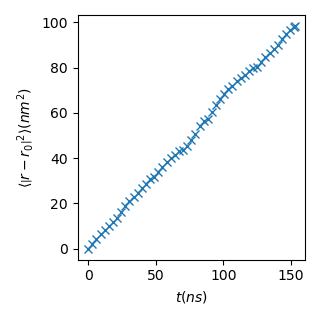
    
Plot the theoretical line over the data to verify the simulation is working as intended. Give the graph appropriate axes, labels, legends etc.
    
Use the plt.show() method at the very end of your code so that the graph is generated in the notebook. Then I can mark it :)

**Hint:** The code below will get you started. Leave it all exactly as it is, but chage the filenames as appropriate. You will find that `brownianTraj.frame[i].pos[j]` will give you the position vector for the $j$th particle on timestep $i$. `brownianTraj.time[i]` gives you the actual, physical time elapsed by the $i$th timestep of your simulation.

**[4 marks]**
</div>

In [ ]:

# Load the Brownian dynamics scripts
bTrajFname = "Brownian_Production.mstraj"  # Replace with your filename
brownianTraj = MDLJTrajectory()
brownianTraj.load(bTrajFname)

bMeasFname = "Brownian_Production.msmeas"  # Replace with your filename
brownianMeas = MDLJMeasurement()
brownianMeas.load(bMeasFname)

# Unwrap the trajectories (to remove periodic boundary wraps and get continuous motion)
# Leave this in at all costs!
brownianTraj.unwrap()



And that's that! If the simulation is giving us the correct diffusion behaviour, we can be relatively confident that it is working as intended. There are other tests we may want to run as well, but we'll save these for another day.

<div class='task'>
    
**Bonus Question:** Justify why your work goes above and beyond what is expected.

For this extra mark, I want to see something interesting. For example:

- Run another simulation with different values and compare the two.
- Describe what sort of physical system this simulation might correspond to, and perhaps attempt to calculate some properties?
- For the simulation type, try to run a "Langevin" simulation instead of a "Brownian" simulation.
    - What is the difference between these two types of simulation? (Hint: Look in the "NumericalIntegrator.py" file in the modules folder, and search "Langevin Equation" online.
    - Can you get it to run without crashing? (Hint: Consider how numerical integration works, and what keeps it stable)

**[1 mark]**
</div>

<!-- END QUESTION -->

---

## Save your assignment and upload

Checklist:
- Restart the kernel and re-run all cells (Kernel > Restart Kernel and Run All Cells)
- Check from top to bottom that every cell has run (has a number inside the square brackets (e.g. `[1]`) next to it)
- Manually run any cells which have not run
- Save your file (File > Save Notebook)
- Upload the .ipynb file to GradeScope
- Check you have uploaded the correct file to GradeScope

## End of Assessment

<hr class='double' />